## Cara Membuat Peta Heatmap Menggunakan Geopandas di Python

Geopandas adalah salah satu library Python yang digunakan untuk membuat peta. Basis penggunaan Geopandas adalah dataframe, sama seperti penggunaan library Pandas. Sebelum menginstall Geopandas, pastikan ketiga library berikut sudah terinstall dengan baik.

- [shapely](https://shapely.readthedocs.io/)
- [pyproj](https://github.com/pyproj4/pyproj)
- [pyogrio](https://pyogrio.readthedocs.io/)

Lalu, Geopanda bisa diinstall dengan perintah

```
pip install geopandas
```

Jika semua sudah diinstall. Kita lanjut ke tahap membuat peta heatmap.

Untuk membuat peta heatmap pada tutorial ini, dibutuhkan file SHP batas administrasi wilayah. Pada tutorial ini, kita menggunakan batas administrasi provinsi di Indonesia. Data yang akan disajikan berupa jumlah mahasiswa di perguruan tinggi negeri dan swasta pada tahun 2024. Data diperoleh dari [BPS](https://www.bps.go.id/id/statistics-table/3/Y21kVGRHNXZVMEl3S3pCRlIyMHJRbnB1WkVZemR6MDkjMyMwMDAw/jumlah-perguruan-tinggi-sup-1-sup-dosen-dan-mahasiswa-negeri-dan-swasta-di-bawah-kementerian-riset-teknologi-dan-pendidikan-tinggi-kementerian-pendidikan-dan-kebudayaan-menurut-provinsi.html?year=2024).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd

c:\Users\auliatdmrc\AppData\Local\Programs\Python\Python38\lib\site-packages\geopandas\_compat.py:124: UserWarning: The Shapely GEOS version (3.8.1-CAPI-1.13.3) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [20]:
# File SHP
file_shp = "D:\SHP\BATAS_PROVINSI_RBI\BATAS_PROVINSI_RBI.shp"

# File Data
file_data = "D:\code\PYTHON\Geopandas_Tutorial\Data\Jumlah_Mahasiswa_PTN_PTS_2024.xlsx"

In [21]:
df_shapefile = gpd.read_file(file_shp)
df_shapefile.head()

,OBJECTID,NAMOBJ,FCODE,REMARK,METADATA,SRS_ID,KDBBPS,KDCBPS,KDCPUM,KDEBPS,...,WADMKK,WADMPR,WIADKC,WIADKK,WIADPR,WIADKD,SHAPE_Leng,SHAPE_Area,KDPKAB_2,geometry
0,498.0,Deiyai,BA03050040,NaN,TASWIL5000020230907KABKOTA,4326,NaN,NaN,NaN,NaN,...,Deiyai,Papua Tengah,NaN,Paniai,Papua,0.0,3.392139,0.231851,9408.0,"MULTIPOLYGON Z (((134.83115 -3.12258 0.00000, ..."
1,7.0,Bolaang Mongondow,BA03050040,NaN,TASWIL5000020230907KABKOTA,4326,NaN,NaN,NaN,NaN,...,Bolaang Mongondow,Sulawesi Utara,NaN,NaN,NaN,0.0,3.657437,0.267425,7101.0,"MULTIPOLYGON Z (((124.35299 0.41822 0.00000, 1..."
2,508.0,Kota Sorong,BA03050040,NaN,TASWIL5000020230907KABKOTA,4326,NaN,NaN,NaN,NaN,...,Kota Sorong,Papua Barat Daya,NaN,Sorong,Papua Barat,0.0,1.229888,0.016677,9671.0,"MULTIPOLYGON Z (((129.72236 -1.86574 0.00000, ..."
3,496.0,Biak Numfor,BA03050040,NaN,TASWIL5000020230907KABKOTA,4326,NaN,NaN,NaN,NaN,...,Biak Numfor,Papua,NaN,NaN,NaN,0.0,5.355326,0.183452,9106.0,"MULTIPOLYGON Z (((135.01582 -1.48624 0.00000, ..."
4,495.0,Asmat,BA03050040,NaN,TASWIL5000020230907KABKOTA,4326,NaN,NaN,NaN,NaN,...,Asmat,Papua Selatan,NaN,Merauke,Papua,0.0,10.505102,2.041032,9304.0,"MULTIPOLYGON Z (((138.49926 -8.32289 0.00000, ..."


In [22]:
# Reading data
df_data = pd.read_excel(file_data)
df_data.head()

,Provinsi,jumlah_mahasiswa_negeri_swasta
0,Aceh,151574
1,Sumatera Utara,404298
2,Sumatera Barat,195540
3,Riau,152254
4,Jambi,67625


Pada file SHP, nama provinsi berada pada kolom WADMPR, sedangkan pada file data, nama kolom provinsi dinamakan sebagai Provinsi. Maka, pada file data, nama kolom perlu diubah menjadi WADMPR. Perubahan ini bertujuan agar kedua data bisa digabung (merge) dengan menggunakan key yang sama, yaitu WADMPR.

In [23]:
df_data.rename(columns={'Provinsi' : 'WADMPR'}, inplace=True)
df_data.head()

,WADMPR,jumlah_mahasiswa_negeri_swasta
0,Aceh,151574
1,Sumatera Utara,404298
2,Sumatera Barat,195540
3,Riau,152254
4,Jambi,67625


In [24]:
df_shapefile_merged = df_shapefile.merge(df_data, on='WADMPR', how='left')
df_shapefile_merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   OBJECTID                        39 non-null     float64 
 1   NAMOBJ                          39 non-null     object  
 2   FCODE                           39 non-null     object  
 3   REMARK                          0 non-null      float64 
 4   METADATA                        39 non-null     object  
 5   SRS_ID                          39 non-null     object  
 6   KDBBPS                          0 non-null      float64 
 7   KDCBPS                          0 non-null      float64 
 8   KDCPUM                          0 non-null      float64 
 9   KDEBPS                          0 non-null      float64 
 10  KDEPUM                          0 non-null      float64 
 11  KDPBPS                          0 non-null      float64 
 12  KDPKAB          

Kemudian, kita akan membuat heatmap dengan menggunakan variabel `jumlah_mahasiswa_negeri_swasta` dari `df_shapefile_merged` dengan menggunakan script sebagai berikut

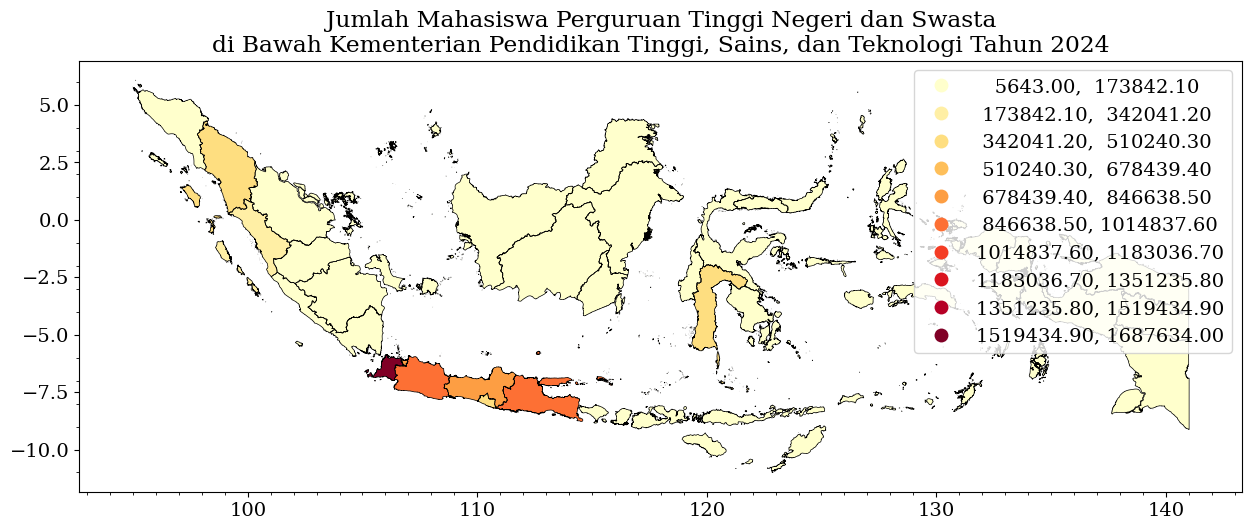

In [30]:
plt.rcParams['font.family'] = "Serif"
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(15,8))

df_shapefile_merged.plot(
    ax=ax,
    column='jumlah_mahasiswa_negeri_swasta',
    cmap='YlOrRd',
    legend=True,
    scheme='equal_interval',
    k=10,
    )

df_shapefile_merged.boundary.plot(ax=ax, color='k', linewidth=0.5)
ax.set_title('Jumlah Mahasiswa Perguruan Tinggi Negeri dan Swasta\ndi Bawah Kementerian Pendidikan Tinggi, Sains, dan Teknologi Tahun 2024')
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(1))

Keterangan legend di atas dihasilkan berdasarkan rentang `equal_interval` sebanyak 10 bagian (k=10). Namun, tampilan heatmap di atas terlihat terganggu oleh letak legend yang menimpa tampilan utama heatmap. Maka, perlu penyesuaian ukuran font legend dengan menambah atribut `fontsize` pada fungsi plot (baris 13). Kita atur ukuran font sebesar 8.

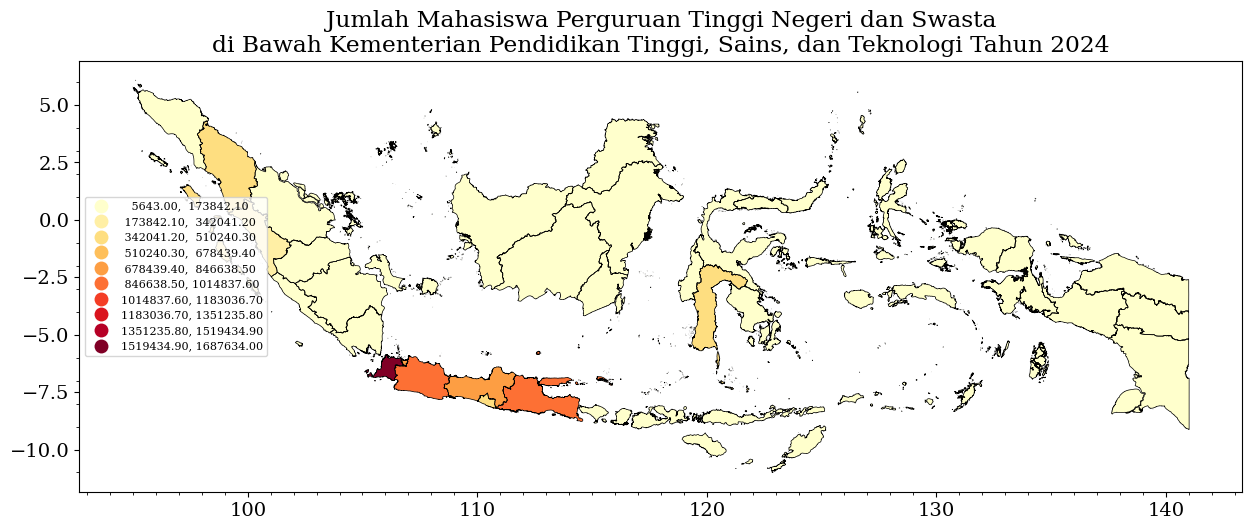

In [34]:
plt.rcParams['font.family'] = "Serif"
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(15,8))

df_shapefile_merged.plot(
    ax=ax,
    column='jumlah_mahasiswa_negeri_swasta',
    cmap='YlOrRd',
    legend=True,
    scheme='equal_interval',
    k=10,
    legend_kwds={"loc": "center left", "fontsize":8}
    )

df_shapefile_merged.boundary.plot(ax=ax, color='k', linewidth=0.5)
ax.set_title('Jumlah Mahasiswa Perguruan Tinggi Negeri dan Swasta\ndi Bawah Kementerian Pendidikan Tinggi, Sains, dan Teknologi Tahun 2024')
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(1))

Tampilan legend masih sedikit menimpa tampilan utama heatmap, maka posisi legend perlu disesuaikan dengan menambahkan script seperti pada baris ke 6 (`x_legend_pos, y_legend_pos = 0.01, 0.2`) untuk mendefinisikan posisi legend. Kemudian penambahan atribut `bbox_to_anchor` pada `legend_kwds` pada baris ke 15. Script pembaharuannya adalah sebagai berikut.

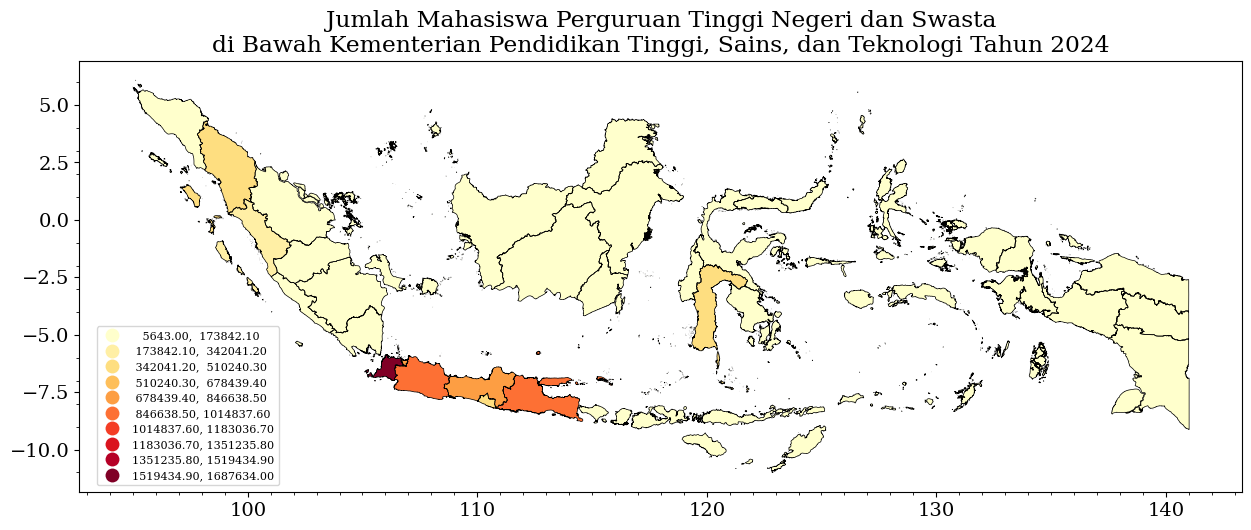

In [38]:
plt.rcParams['font.family'] = "Serif"
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(15,8))

x_legend_pos, y_legend_pos = 0.01, 0.2

df_shapefile_merged.plot(
    ax=ax,
    column='jumlah_mahasiswa_negeri_swasta',
    cmap='YlOrRd',
    legend=True,
    scheme='equal_interval',
    k=10,
    legend_kwds={"loc": "center left", "fontsize":8, "bbox_to_anchor": (x_legend_pos, y_legend_pos)}
    )

df_shapefile_merged.boundary.plot(ax=ax, color='k', linewidth=0.5)
ax.set_title('Jumlah Mahasiswa Perguruan Tinggi Negeri dan Swasta\ndi Bawah Kementerian Pendidikan Tinggi, Sains, dan Teknologi Tahun 2024')
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(1))

`x_legend_pos` dan `y_legend_pos` bisa disesuaikan dengan kebutuhan untuk mengatur letak legend. Nilai x yang bertambah, maka posisi legend akan bergeser ke kanan dan nilai y bertambah, maka posisi legend akan naik ke atas. Kemudian, kita bisa menambahkan judul legend pada atribut `legend_kdws` dengan keterangan `title:` dengan ukurannya, `title_fontsize` di atur sebesar 8 seperti pada baris ke 15 berikut

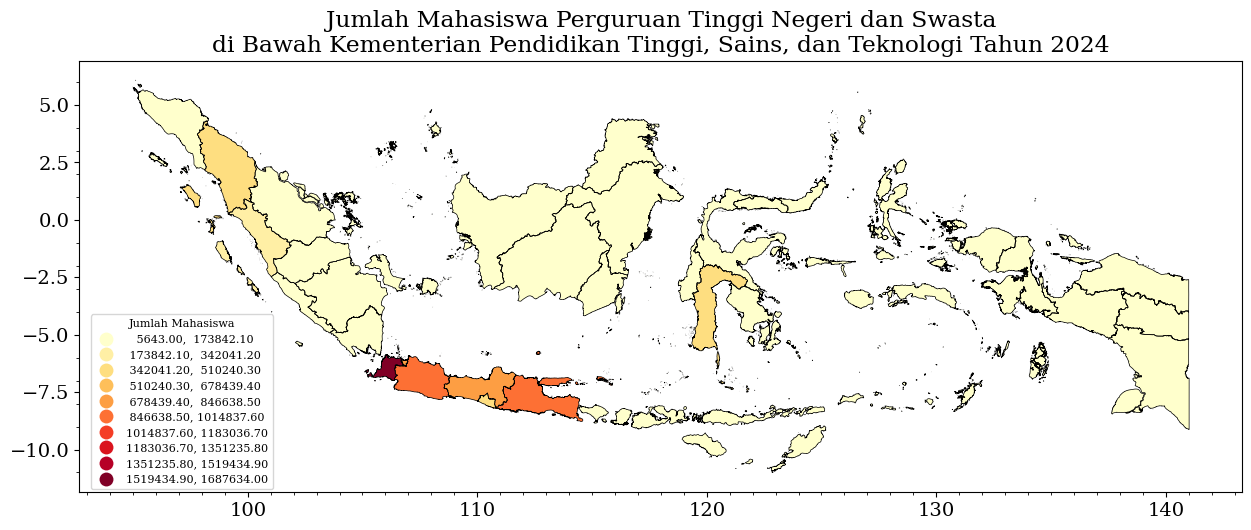

In [45]:
plt.rcParams['font.family'] = "Serif"
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(15,8))

x_legend_pos, y_legend_pos = 0.005, 0.21

df_shapefile_merged.plot(
    ax=ax,
    column='jumlah_mahasiswa_negeri_swasta',
    cmap='YlOrRd',
    legend=True,
    scheme='equal_interval',
    k=10,
    legend_kwds={"loc": "center left", "fontsize":8, "bbox_to_anchor": (x_legend_pos, y_legend_pos), "title":"Jumlah Mahasiswa", "title_fontsize":8,}
    )

df_shapefile_merged.boundary.plot(ax=ax, color='k', linewidth=0.5)
ax.set_title('Jumlah Mahasiswa Perguruan Tinggi Negeri dan Swasta\ndi Bawah Kementerian Pendidikan Tinggi, Sains, dan Teknologi Tahun 2024')
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(1))

Jika kita lihat lebih lanjut, tampilan rentang pada legend dipisahkan oleh tanda koma. Agar lebih sesuai, kita bisa modifikasi pemisahannya dengan tanda "-". Modifikasi ini dilakukan dengan menambah script seperti pada baris 18-23 sebagai berikut.

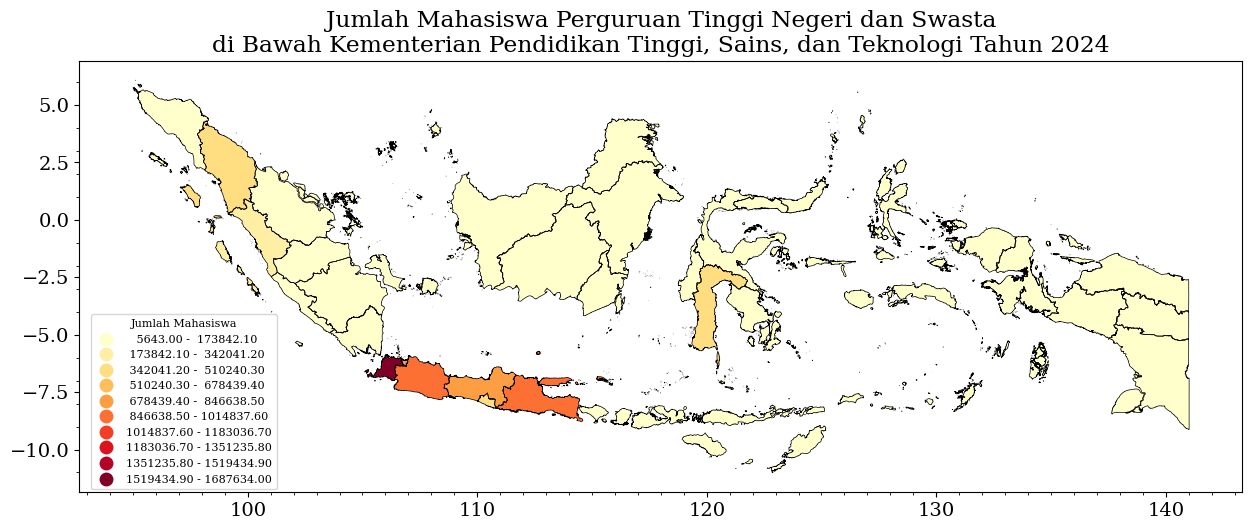

In [46]:
plt.rcParams['font.family'] = "Serif"
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(15,8))

x_legend_pos, y_legend_pos = 0.005, 0.21

df_shapefile_merged.plot(
    ax=ax,
    column='jumlah_mahasiswa_negeri_swasta',
    cmap='YlOrRd',
    legend=True,
    scheme='equal_interval',
    k=10,
    legend_kwds={"loc": "center left", "fontsize":8, "bbox_to_anchor": (x_legend_pos, y_legend_pos), "title":"Jumlah Mahasiswa", "title_fontsize":8,}
    )

legend = ax.get_legend()
# Iterate through the legend text items and replace the commas
for text in legend.get_texts():
    current_label = text.get_text()
    new_label = current_label.replace(',', ' -') # Replace ' , ' with ' - '
    text.set_text(new_label)

df_shapefile_merged.boundary.plot(ax=ax, color='k', linewidth=0.5)
ax.set_title('Jumlah Mahasiswa Perguruan Tinggi Negeri dan Swasta\ndi Bawah Kementerian Pendidikan Tinggi, Sains, dan Teknologi Tahun 2024')
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(1))